In [1]:
#load data
import pandas as pd
data_path="../data/auto_mpg.csv"
dataset=pd.read_csv(data_path)
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [2]:
#dataset shape
dataset.shape

(398, 8)

In [3]:
#null values
dataset.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [4]:
#drop null values
dataset=dataset.dropna()
dataset.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [5]:
#origin column is categorical
#1 usa
#2 europe
#3 japan
dataset['Origin'].value_counts()


Origin
1    245
3     79
2     68
Name: count, dtype: int64

In [6]:
#convert origin column to categorical
dataset['Origin']=dataset['Origin'].map(
    {1:'USA',
     2:'Europe',
     3:'Japan'})
dataset['Origin'].value_counts()

Origin
USA       245
Japan      79
Europe     68
Name: count, dtype: int64

In [7]:
#use one hot encoding to convert categorical column to numerical(not so efficient)
dataset=pd.get_dummies(dataset,columns=['Origin'],prefix='',prefix_sep='')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Europe        392 non-null    bool   
 8   Japan         392 non-null    bool   
 9   USA           392 non-null    bool   
dtypes: bool(3), float64(5), int64(2)
memory usage: 25.6 KB


In [8]:
#train test splittg
train_dataset=dataset.sample(frac=0.8, random_state=0)
test_dataset=dataset.drop(train_dataset.index)

In [9]:
import seaborn as sns
sns.pairplot(train_dataset[['MPG','Cylinders','Displacement','Horsepower','Weight']],diag_kind='kde')

d:\universidad\2026\2\analitica predictiva\std-simon-zapata-naranjo\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\universidad\2026\2\analitica predictiva\std-simon-zapata-naranjo\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\universidad\2026\2\analitica predictiva\std-simon-zapata-naranjo\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\universidad\2026\2\analitica predictiva\std-simon-za

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


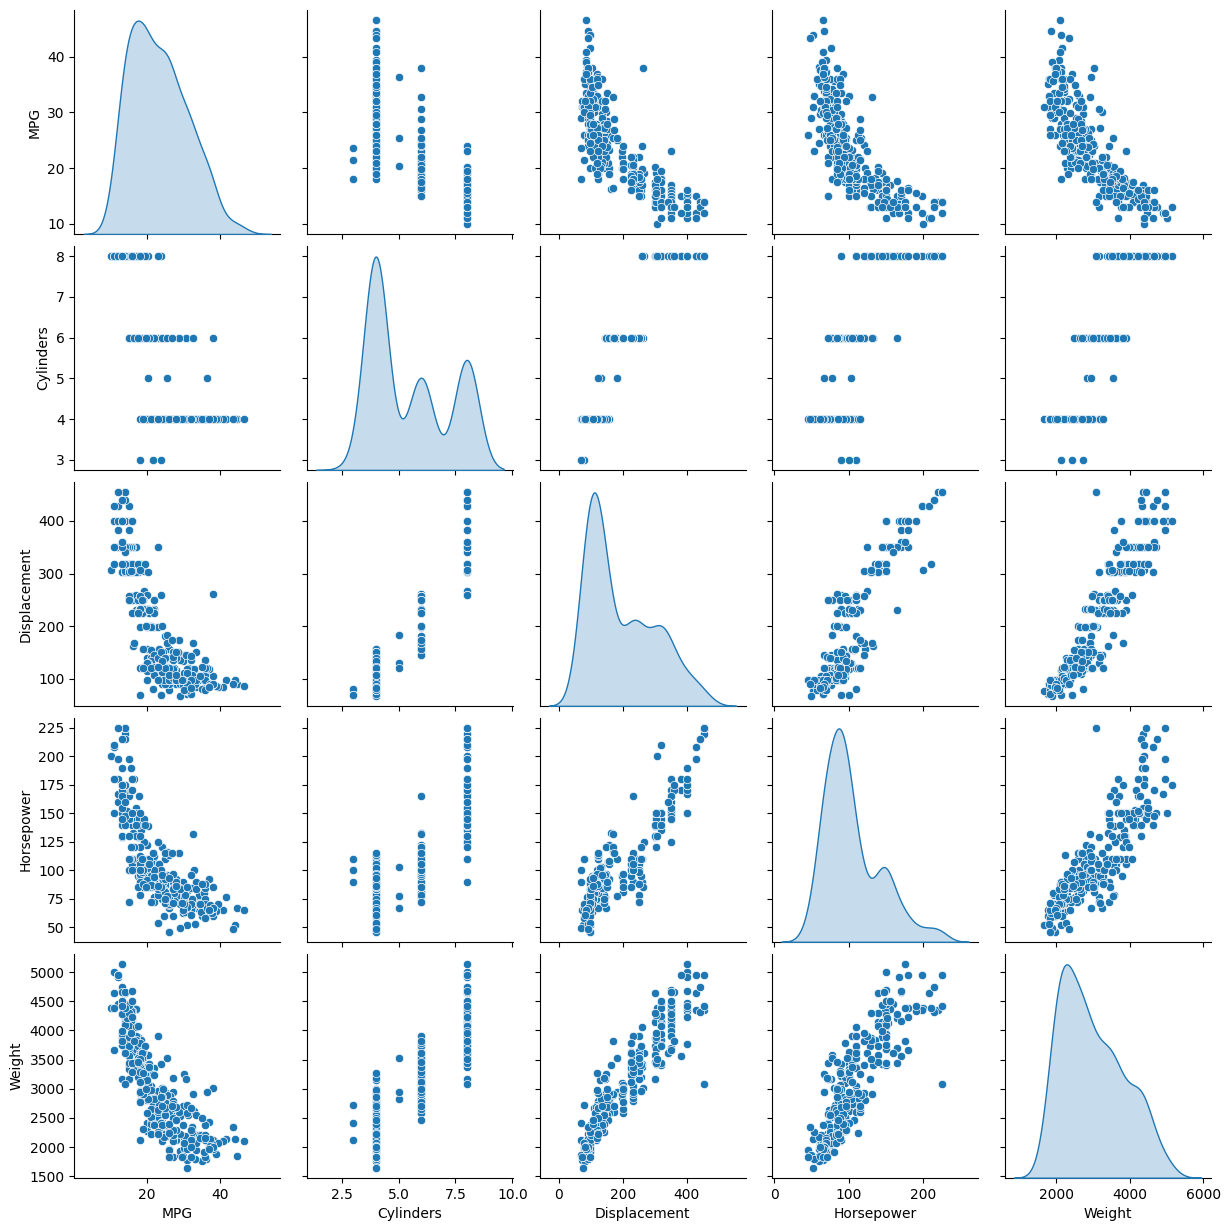

In [10]:
#get statistics
train_stats=train_dataset.describe().transpose()
train_stats

In [11]:
#features and labels
train_features=train_dataset.copy()
train_label=train_features.pop('MPG')

test_features=test_dataset.copy()
test_label=test_features.pop('MPG')

In [12]:
#standardize data
train_stats[['mean','std']]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
pd.DataFrame(
    scaler.fit_transform(train_dataset),
    columns=train_dataset.columns
).describe().transpose()[['mean','std']]

,mean,std
MPG,-2.206303e-16,1.001596
Cylinders,2.022444e-16,1.001596
Displacement,7.990777e-17,1.001596
Horsepower,-1.980016e-17,1.001596
Weight,-9.051500e-17,1.001596
Acceleration,-5.275327e-16,1.001596
Model Year,9.419217e-16,1.001596
Europe,3.394312e-17,1.001596
Japan,2.828594e-18,1.001596
USA,1.697156e-17,1.001596


In [14]:

# %%
# lineal regression with one feature(Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)




In [15]:
# %%
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_label)
print(f"function: y = {horsepower_model.coef_[0]:.2f} * x + {horsepower_model.intercept_:.2f}")

function: y = -5.90 * x + 23.31


d:\universidad\2026\2\analitica predictiva\std-simon-zapata-naranjo\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\universidad\2026\2\analitica predictiva\std-simon-zapata-naranjo\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\universidad\2026\2\analitica predictiva\std-simon-zapata-naranjo\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


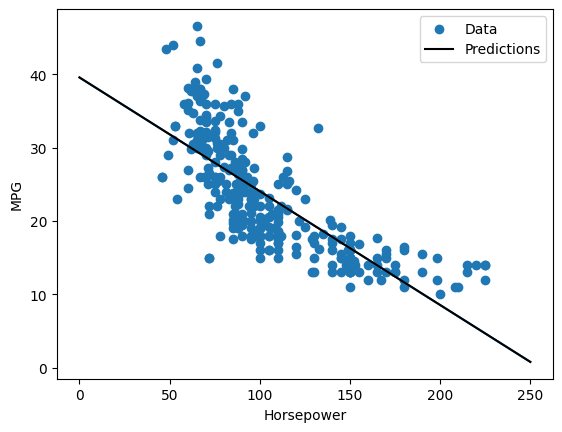

In [16]:
import numpy as np
x=pd.DataFrame(np.linspace(0,250,251))
x_standarized=horsepower_scaler.transform(x)
y=horsepower_model.predict(x_standarized)
sns.lineplot(x=x[0],y=y)
# %%
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_label, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()
plot_horsepower(x[0], y)

In [17]:
# Evaluación

from sklearn.metrics import mean_squared_error

test_results = {}

y_pred = horsepower_model.predict(standarized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_label,
    y_pred=y_pred,
)

test_results


{'horsepower_model': 20.829300555790315}

In [18]:
#lineal regression with multiple features
features_scaler = StandardScaler()
features_scaler.fit(train_features)

standarized_train_features = features_scaler.transform(train_features)
standarized_test_features = features_scaler.transform(test_features)
linear_model = LinearRegression()
linear_model.fit(standarized_train_features, train_label)


LinearRegression()

In [19]:
#intercept and coefficients
print(f"intercept: {linear_model.intercept_:.2f}")
print(f"coefficients: {linear_model.coef_}")

intercept: 23.31
coefficients: [-0.78715361  2.40329414 -1.35280162 -5.10984346 -0.26461302  2.92072687
  0.42671757  0.57369578 -0.80879752]


In [20]:
test_results = {}

y_pred = linear_model.predict(standarized_test_features)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_label,
    y_pred=y_pred,
)

test_results

{'horsepower_model': 10.1720922836876}

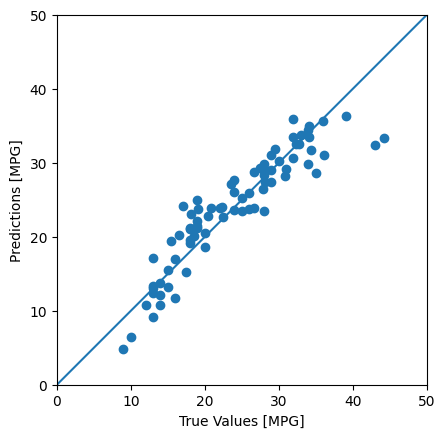

In [21]:
#plot predictions
def plot_predictions(y_true, y_pred):

    ax = plt.axes(aspect="equal")
    plt.scatter(y_true, y_pred)
    plt.xlabel("True Values [MPG]")
    plt.ylabel("Predictions [MPG]")
    lims = [0, 50]
    plt.xlim(lims)
    plt.ylim(lims)
    _ = plt.plot(lims, lims)
    
plot_predictions(test_label,y_pred)

{'horsepower_model': 10.1720922836876, 'mlp_horsepower': 12.806525974883083}

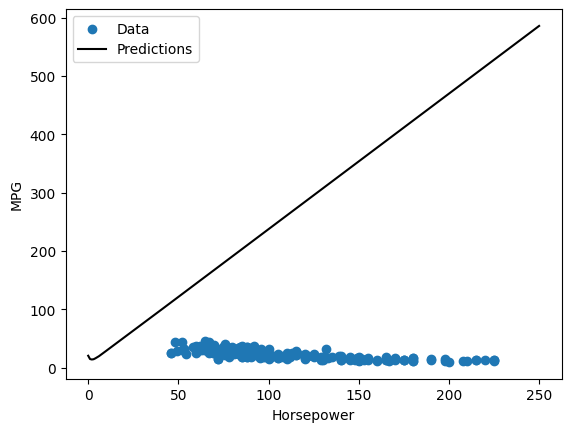

In [22]:
# Red neuronal con una sola entrada (Horsepower)

from sklearn.neural_network import MLPRegressor

mlp_horsepower = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)
mlp_horsepower.fit(standarized_train_horsepower, train_label)

y = mlp_horsepower.predict(x)
plot_horsepower(x, y)

y_pred = mlp_horsepower.predict(standarized_test_horsepower)

test_results["mlp_horsepower"] = mean_squared_error(
    y_true=test_label,
    y_pred=y_pred,
)

test_results




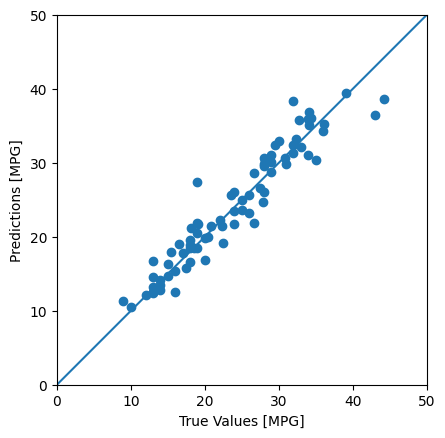

In [23]:
# Red neuronal con todas las variables

mlp = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)

mlp.fit(standarized_train_features, train_label)

test_predictions = mlp.predict(standarized_test_features)

plot_predictions(
    y_true=test_label,
    y_pred=test_predictions,
)






test_results["mlp"] = mean_squared_error(
    y_true=test_label,
    y_pred=test_predictions,)

In [24]:
test_results["mlp"] = mean_squared_error(
    y_true=test_label,
    y_pred=test_predictions,
)
test_results

{'horsepower_model': 10.1720922836876,
 'mlp_horsepower': 12.806525974883083,
 'mlp': 5.954688727680057}

In [25]:

# almacenamiento de los modelos y del scaler de features

import os
import pickle


with open("../submission/mlp.pkl", "wb") as file:
    pickle.dump(mlp, file)

with open("../submission/features_scaler.pkl", "wb") as file:
    pickle.dump(features_scaler, file)


In [26]:
# Uso del modelo

import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset = dataset.dropna()
dataset["Origin"] = dataset["Origin"].map(
    {1: "USA", 2: "Europe", 3: "Japan"},
)
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
y_true = dataset.pop("MPG")

with open("../submission/mlp.pkl", "rb") as file:
    new_mlp = pickle.load(file)

with open("../submission/features_scaler.pkl", "rb") as file:
    new_features_scaler = pickle.load(file)

standarized_dataset = new_features_scaler.transform(dataset)
y_pred = new_mlp.predict(standarized_dataset)

mean_squared_error(
    y_true=y_true,
    y_pred=y_pred,
)


7.744565284379876